# Quantitative Evaluation

We evaluate the Bayesian Network as a binary classifier and compare it against four sklearn baselines using **5-fold stratified cross-validation**.

**Metrics:** Accuracy, Precision, Recall, F1, AUC-ROC, Log-Likelihood, Brier Score, Predictive Entropy, ECE  
**Baselines:** Logistic Regression, Naive Bayes (Categorical), Random Forest, SVM

**Classification procedure:** For each test sample, all non-target features are provided as evidence to Variable Elimination, yielding P(num=1 | evidence). Predictions are made at threshold 0.5.


In [1]:
## Setup — imports, data loading, discretization, and BN structure
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from pgmpy.models import DiscreteBayesianNetwork, MarkovNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator
from pgmpy.inference import VariableElimination, BeliefPropagation
from pgmpy.factors.discrete import DiscreteFactor

# ── Load raw data ──────────────────────────────────────────────────────────────
df = pd.read_csv('heart_disease_cleaned.csv')
print(f'Loaded: {df.shape[0]} rows × {df.shape[1]} cols')

# ── Discretization ─────────────────────────────────────────────────────────────
df_disc = df.copy()

# Target: binarize num (0 = healthy, 1 = disease)
df_disc['num'] = (df_disc['num'] > 0).astype(int)

# age: (0,45]=0, (45,60]=1, (60,∞]=2
df_disc['age'] = pd.cut(df_disc['age'], bins=[0, 45, 60, float('inf')],
                         labels=[0, 1, 2]).astype(int)
# trestbps: <130=0, >=130=1
df_disc['trestbps'] = (df_disc['trestbps'] >= 130).astype(int)
# chol: <200=0, 200-240=1, >240=2
df_disc['chol'] = pd.cut(df_disc['chol'], bins=[0, 199, 240, float('inf')],
                          labels=[0, 1, 2]).astype(int)
# thalach: <120=0, 120-150=1, >150=2
df_disc['thalach'] = pd.cut(df_disc['thalach'], bins=[0, 119, 150, float('inf')],
                             labels=[0, 1, 2]).astype(int)
# oldpeak: <=1=0, (1,2]=1, >2=2
df_disc['oldpeak'] = pd.cut(df_disc['oldpeak'], bins=[-0.001, 1.0, 2.0, float('inf')],
                             labels=[0, 1, 2]).astype(int)
# cp: 1-4 → 0-3
df_disc['cp'] = (df_disc['cp'] - 1).astype(int)
# slope: 1-3 → 0-2
df_disc['slope'] = (df_disc['slope'] - 1).astype(int)
# thal: {3,6,7} → {0,1,2}
thal_map = {3: 0, 6: 1, 7: 2}
df_disc['thal'] = df_disc['thal'].astype(float).round().astype(int).map(thal_map)
# Already 0-indexed integers
for col in ['ca', 'sex', 'fbs', 'restecg', 'exang']:
    df_disc[col] = df_disc[col].astype(float).round().astype(int)

assert df_disc.isnull().sum().sum() == 0, 'NaNs found after discretization!'
print('Discretization complete. Zero NaNs confirmed.')

# ── BN / MRF structure ─────────────────────────────────────────────────────────
RISK_FACTORS = ['age', 'sex', 'fbs', 'chol', 'trestbps']
DISEASE      = ['num']
SYMPTOMS     = ['cp', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'restecg']

edges = [(rf, 'num') for rf in RISK_FACTORS] + \
        [('num', sym) for sym in SYMPTOMS]

# Enriched DAG: 4 extra domain-knowledge edges
extra_edges = [
    ('age',      'thalach'),   # age directly lowers max heart rate
    ('sex',      'cp'),        # sex shapes chest-pain presentation
    ('chol',     'oldpeak'),   # cholesterol → ST depression
    ('trestbps', 'exang'),     # high BP → exercise-induced angina
]
enriched_edges = edges + extra_edges

state_names = {
    'age':      [0, 1, 2],
    'sex':      [0, 1],
    'fbs':      [0, 1],
    'chol':     [0, 1, 2],
    'trestbps': [0, 1],
    'num':      [0, 1],
    'cp':       [0, 1, 2, 3],
    'thalach':  [0, 1, 2],
    'exang':    [0, 1],
    'oldpeak':  [0, 1, 2],
    'slope':    [0, 1, 2],
    'ca':       [0, 1, 2, 3],
    'thal':     [0, 1, 2],
    'restecg':  [0, 1, 2],
}

print(f'BN/MRF structure: {len(edges)} edges (basic), {len(enriched_edges)} edges (enriched), {len(state_names)} nodes')
print(f'df_disc shape: {df_disc.shape}')


Loaded: 303 rows × 14 cols
Discretization complete. Zero NaNs confirmed.
BN/MRF structure: 13 edges (basic), 17 edges (enriched), 14 nodes
df_disc shape: (303, 14)


In [2]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    log_loss, brier_score_loss, mutual_info_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import CategoricalNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

print('Evaluation libraries imported successfully.')


# ── BN prediction helper ──────────────────────────────────────────────────────
def bn_predict_proba(model, test_df, target='num'):
    """
    Return P(num=1 | all other features) for every row in test_df.
    Uses Variable Elimination; falls back to 0.5 on any VE failure.
    """
    ve = VariableElimination(model)
    feature_cols = [c for c in test_df.columns if c != target]
    proba = []
    for _, row in test_df.iterrows():
        evidence = {c: int(row[c]) for c in feature_cols}
        try:
            q = ve.query([target], evidence=evidence, show_progress=False)
            proba.append(float(q.values[1]))   # P(num=1)
        except Exception:
            proba.append(0.5)                  # safe fallback
    return np.array(proba)


# ── MRF helpers ───────────────────────────────────────────────────────────────
def build_mrf_from_data(data, edge_list, state_names_dict, alpha=1.0, edge_weights=None, gamma=0.0):
    """Build MRF with unary + pairwise factors; optional MI-based edge reweighting."""
    model = MarkovNetwork()
    model.add_nodes_from(state_names_dict.keys())
    model.add_edges_from(edge_list)

    for node, states in state_names_dict.items():
        counts = data[node].value_counts().reindex(states, fill_value=0).astype(float).values
        probs = (counts + alpha) / (counts.sum() + alpha * len(states))
        model.add_factors(DiscreteFactor(
            variables=[node], cardinality=[len(states)],
            values=probs, state_names={node: states},
        ))

    for u, v in edge_list:
        states_u = state_names_dict[u]
        states_v = state_names_dict[v]
        tab = pd.crosstab(data[u], data[v], dropna=False)
        tab = tab.reindex(index=states_u, columns=states_v, fill_value=0).astype(float)
        phi_uv = (tab.values + alpha)
        phi_uv = phi_uv / phi_uv.sum()
        if edge_weights is not None and gamma > 0:
            key = tuple(sorted((u, v)))
            w = edge_weights.get(key, 0.0)
            phi_uv = np.power(phi_uv, 1.0 + gamma * w)
            phi_uv = phi_uv / phi_uv.sum()
        model.add_factors(DiscreteFactor(
            variables=[u, v], cardinality=[len(states_u), len(states_v)],
            values=phi_uv, state_names={u: states_u, v: states_v},
        ))

    assert model.check_model(), 'MRF model check failed'
    return model


def mrf_predict_proba(model, test_df, target='num'):
    """Return P(num=1 | all other features) for every row in test_df."""
    bp_inf = BeliefPropagation(model)
    feat_cols = [c for c in test_df.columns if c != target]
    proba = []
    for _, row in test_df.iterrows():
        evidence = {c: int(row[c]) for c in feat_cols}
        try:
            q = bp_inf.query(variables=[target], evidence=evidence, show_progress=False)
            proba.append(float(q.values[1]))
        except Exception:
            proba.append(0.5)
    return np.array(proba)


# ── Additional metric helpers ─────────────────────────────────────────────────
def predictive_entropy(proba):
    """Mean binary entropy of predicted probabilities (bits)."""
    p = np.clip(proba, 1e-10, 1 - 1e-10)
    return np.mean(-p * np.log2(p) - (1 - p) * np.log2(1 - p))


def expected_calibration_error(y_true, y_prob, n_bins=10):
    """Expected Calibration Error (ECE) with equal-width bins."""
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0:
            continue
        bin_acc  = y_true[mask].mean()
        bin_conf = y_prob[mask].mean()
        ece += mask.sum() * abs(bin_acc - bin_conf)
    return ece / len(y_true)


print('All helpers defined.')
print(f"Feature columns ({len([c for c in df_disc.columns if c != 'num'])}):",
      [c for c in df_disc.columns if c != 'num'])


Evaluation libraries imported successfully.
All helpers defined.
Feature columns (13): ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [3]:
## 5-Fold Stratified Cross-Validation
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

MODEL_NAMES = ['BayesianNetwork', 'BN_BDeu', 'BN_Enriched', 'LogisticRegression', 'NaiveBayes', 'RandomForest', 'SVM', 'MRF']

ALL_METRICS = ['accuracy', 'precision', 'recall', 'f1', 'auc',
               'log_likelihood', 'brier', 'entropy', 'ece']

# Storage: per-fold metrics and pooled predictions (for aggregate ROC)
cv_results  = {m: {metric: [] for metric in ALL_METRICS} for m in MODEL_NAMES}
pool_true   = {m: [] for m in MODEL_NAMES}
pool_proba  = {m: [] for m in MODEL_NAMES}

X_np = df_disc.drop('num', axis=1).values
y_np = df_disc['num'].values

print(f"5-fold stratified CV  |  {len(y_np)} samples  |  class balance {(y_np==0).sum()}/{(y_np==1).sum()}\n")

for fold_i, (train_idx, test_idx) in enumerate(skf.split(X_np, y_np)):
    print(f"── Fold {fold_i+1}/{N_SPLITS}  (train={len(train_idx)}, test={len(test_idx)}) ──")

    train_df_f = df_disc.iloc[train_idx].reset_index(drop=True)
    test_df_f  = df_disc.iloc[test_idx].reset_index(drop=True)
    X_tr, X_te = X_np[train_idx], X_np[test_idx]
    y_tr, y_te = y_np[train_idx], y_np[test_idx]

    # ── Bayesian Network ──────────────────────────────────────────────────────
    bn_f = DiscreteBayesianNetwork(edges)
    bn_f.fit(train_df_f, estimator=MaximumLikelihoodEstimator, state_names=state_names)
    p_bn   = bn_predict_proba(bn_f, test_df_f)
    yp_bn  = (p_bn >= 0.5).astype(int)

    # ── BN (BDeu prior) ───────────────────────────────────────────────────────
    bn_bdeu_f = DiscreteBayesianNetwork(edges)
    bn_bdeu_f.fit(train_df_f, estimator=BayesianEstimator, state_names=state_names,
                  prior_type='BDeu', equivalent_sample_size=10)
    p_bn_bdeu  = bn_predict_proba(bn_bdeu_f, test_df_f)
    yp_bn_bdeu = (p_bn_bdeu >= 0.5).astype(int)

    # ── BN (BDeu + Enriched DAG) ──────────────────────────────────────────────
    bn_enr_f = DiscreteBayesianNetwork(enriched_edges)
    bn_enr_f.fit(train_df_f, estimator=BayesianEstimator, state_names=state_names,
                 prior_type='BDeu', equivalent_sample_size=10)
    p_bn_enr  = bn_predict_proba(bn_enr_f, test_df_f)
    yp_bn_enr = (p_bn_enr >= 0.5).astype(int)

    # ── Logistic Regression ───────────────────────────────────────────────────
    lr     = LogisticRegression(random_state=42, max_iter=1000)
    lr.fit(X_tr, y_tr)
    p_lr   = lr.predict_proba(X_te)[:, 1]
    yp_lr  = lr.predict(X_te)

    # ── Naive Bayes (Categorical) ─────────────────────────────────────────────
    nb     = CategoricalNB()
    nb.fit(X_tr, y_tr)
    p_nb   = nb.predict_proba(X_te)[:, 1]
    yp_nb  = nb.predict(X_te)

    # ── Random Forest ─────────────────────────────────────────────────────────
    rf     = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_tr, y_tr)
    p_rf   = rf.predict_proba(X_te)[:, 1]
    yp_rf  = rf.predict(X_te)

    # ── SVM ───────────────────────────────────────────────────────────────────
    svm    = SVC(kernel='rbf', probability=True, random_state=42)
    svm.fit(X_tr, y_tr)
    p_svm  = svm.predict_proba(X_te)[:, 1]
    yp_svm = svm.predict(X_te)

    # ── MRF ───────────────────────────────────────────────────────────────────
    mrf_f  = build_mrf_from_data(train_df_f, edges, state_names, alpha=1.0)
    p_mrf  = mrf_predict_proba(mrf_f, test_df_f)
    yp_mrf = (p_mrf >= 0.5).astype(int)

    # ── Record metrics ────────────────────────────────────────────────────────
    fold_data = [
        ('BayesianNetwork',    yp_bn,      p_bn),
        ('BN_BDeu',            yp_bn_bdeu, p_bn_bdeu),
        ('BN_Enriched',        yp_bn_enr,  p_bn_enr),
        ('LogisticRegression', yp_lr,  p_lr),
        ('NaiveBayes',         yp_nb,  p_nb),
        ('RandomForest',       yp_rf,  p_rf),
        ('SVM',                yp_svm, p_svm),
        ('MRF',                yp_mrf, p_mrf),
    ]
    for name, yp, pp in fold_data:
        cv_results[name]['accuracy'].append(accuracy_score(y_te, yp))
        cv_results[name]['precision'].append(precision_score(y_te, yp, zero_division=0))
        cv_results[name]['recall'].append(recall_score(y_te, yp, zero_division=0))
        cv_results[name]['f1'].append(f1_score(y_te, yp, zero_division=0))
        cv_results[name]['auc'].append(roc_auc_score(y_te, pp))
        cv_results[name]['log_likelihood'].append(-log_loss(y_te, pp))   # higher = better
        cv_results[name]['brier'].append(brier_score_loss(y_te, pp))     # lower = better
        cv_results[name]['entropy'].append(predictive_entropy(pp))
        cv_results[name]['ece'].append(expected_calibration_error(y_te, pp))
        pool_true[name].extend(y_te)
        pool_proba[name].extend(pp)

    # ── Fold summary ──────────────────────────────────────────────────────────
    for name in MODEL_NAMES:
        acc_v = cv_results[name]['accuracy'][-1]
        f1_v  = cv_results[name]['f1'][-1]
        auc_v = cv_results[name]['auc'][-1]
        ll_v  = cv_results[name]['log_likelihood'][-1]
        bs_v  = cv_results[name]['brier'][-1]
        ece_v = cv_results[name]['ece'][-1]
        print(f"  {name:<22}  acc={acc_v:.3f}  f1={f1_v:.3f}  auc={auc_v:.3f}"
              f"  ll={ll_v:.3f}  brier={bs_v:.3f}  ece={ece_v:.3f}")
    print()

print('Cross-validation complete.')


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'num': 'N'}


5-fold stratified CV  |  303 samples  |  class balance 164/139

── Fold 1/5  (train=242, test=61) ──


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N

  BayesianNetwork         acc=0.836  f1=0.828  auc=0.888  ll=-1.520  brier=0.128  ece=0.100
  BN_BDeu                 acc=0.836  f1=0.828  auc=0.934  ll=-0.372  brier=0.109  ece=0.107
  BN_Enriched             acc=0.836  f1=0.828  auc=0.934  ll=-0.388  brier=0.119  ece=0.126
  LogisticRegression      acc=0.902  f1=0.893  auc=0.940  ll=-0.306  brier=0.090  ece=0.096
  NaiveBayes              acc=0.885  f1=0.877  auc=0.946  ll=-0.320  brier=0.094  ece=0.095
  RandomForest            acc=0.852  f1=0.836  auc=0.952  ll=-0.336  brier=0.103  ece=0.114
  SVM                     acc=0.902  f1=0.889  auc=0.949  ll=-0.308  brier=0.087  ece=0.104
  MRF                     acc=0.852  f1=0.816  auc=0.946  ll=-0.406  brier=0.120  ece=0.135

── Fold 2/5  (train=242, test=61) ──


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'num': 'N'}


  BayesianNetwork         acc=0.754  f1=0.717  auc=0.799  ll=-2.958  brier=0.219  ece=0.162
  BN_BDeu                 acc=0.787  f1=0.745  auc=0.879  ll=-0.637  brier=0.179  ece=0.169
  BN_Enriched             acc=0.787  f1=0.755  auc=0.883  ll=-0.638  brier=0.182  ece=0.169
  LogisticRegression      acc=0.820  f1=0.792  auc=0.889  ll=-0.440  brier=0.135  ece=0.122
  NaiveBayes              acc=0.787  f1=0.755  auc=0.883  ll=-0.601  brier=0.164  ece=0.165
  RandomForest            acc=0.787  f1=0.772  auc=0.871  ll=-0.476  brier=0.150  ece=0.112
  SVM                     acc=0.820  f1=0.792  auc=0.868  ll=-0.465  brier=0.146  ece=0.075
  MRF                     acc=0.770  f1=0.708  auc=0.883  ll=-0.785  brier=0.196  ece=0.207

── Fold 3/5  (train=242, test=61) ──


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'num': 'N'}


  BayesianNetwork         acc=0.836  f1=0.815  auc=0.857  ll=-2.118  brier=0.145  ece=0.151
  BN_BDeu                 acc=0.869  f1=0.852  auc=0.915  ll=-0.434  brier=0.116  ece=0.109
  BN_Enriched             acc=0.836  f1=0.821  auc=0.918  ll=-0.401  brier=0.111  ece=0.109
  LogisticRegression      acc=0.820  f1=0.792  auc=0.902  ll=-0.378  brier=0.119  ece=0.100
  NaiveBayes              acc=0.836  f1=0.821  auc=0.913  ll=-0.417  brier=0.115  ece=0.113
  RandomForest            acc=0.820  f1=0.807  auc=0.896  ll=-0.932  brier=0.125  ece=0.142
  SVM                     acc=0.852  f1=0.836  auc=0.884  ll=-0.409  brier=0.127  ece=0.091
  MRF                     acc=0.803  f1=0.739  auc=0.913  ll=-0.563  brier=0.131  ece=0.167

── Fold 4/5  (train=243, test=60) ──


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'num': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'N', 'sex': 'N', 'cp': 'N', 'trestbps': 'N', 'chol': 'N', 'fbs': 'N', 'restecg': 'N', 'thalach': 'N', 'exang': 'N', 'oldpeak': 'N', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'num': 'N'}


  BayesianNetwork         acc=0.700  f1=0.679  auc=0.744  ll=-4.099  brier=0.240  ece=0.189
  BN_BDeu                 acc=0.750  f1=0.737  auc=0.862  ll=-0.680  brier=0.187  ece=0.163
  BN_Enriched             acc=0.767  f1=0.759  auc=0.859  ll=-0.675  brier=0.184  ece=0.152
  LogisticRegression      acc=0.783  f1=0.764  auc=0.915  ll=-0.392  brier=0.133  ece=0.129
  NaiveBayes              acc=0.800  f1=0.778  auc=0.900  ll=-0.507  brier=0.148  ece=0.146
  RandomForest            acc=0.817  f1=0.784  auc=0.878  ll=-0.419  brier=0.138  ece=0.083
  SVM                     acc=0.783  f1=0.764  auc=0.878  ll=-0.433  brier=0.143  ece=0.103
  MRF                     acc=0.800  f1=0.750  auc=0.900  ll=-0.607  brier=0.163  ece=0.164

── Fold 5/5  (train=243, test=60) ──
  BayesianNetwork         acc=0.733  f1=0.652  auc=0.686  ll=-5.804  brier=0.249  ece=0.225
  BN_BDeu                 acc=0.817  f1=0.766  auc=0.888  ll=-0.612  brier=0.162  ece=0.166
  BN_Enriched             acc=0.833  f1=0.

In [4]:
## Summary Table — Mean ± Std across 5 folds

print(f"\n{'─'*100}")
print("Mean scores only (↑ = higher is better, ↓ = lower is better):")
print(f"{'─'*100}")

mean_df = pd.DataFrame({
    name: {m: np.mean(v) for m, v in cv_results[name].items()}
    for name in MODEL_NAMES
}).T.round(4)
mean_df.index.name = 'Model'

# Rename columns for clarity
mean_df = mean_df.rename(columns={
    'log_likelihood': 'log_lik (↑)',
    'brier':          'brier (↓)',
    'entropy':        'entropy',
    'ece':            'ece (↓)',
    'accuracy':       'accuracy (↑)',
    'precision':      'precision (↑)',
    'recall':         'recall (↑)',
    'f1':             'f1 (↑)',
    'auc':            'auc (↑)',
})
print(mean_df.to_string())

print(f"\n{'─'*100}")
print("Std across folds:")
print(f"{'─'*100}")
std_df = pd.DataFrame({
    name: {m: np.std(v) for m, v in cv_results[name].items()}
    for name in MODEL_NAMES
}).T.round(4)
std_df.index.name = 'Model'
std_df = std_df.rename(columns={
    'log_likelihood': 'log_lik',
    'brier': 'brier', 'entropy': 'entropy', 'ece': 'ece',
})
print(std_df.to_string())



────────────────────────────────────────────────────────────────────────────────────────────────────
Mean scores only (↑ = higher is better, ↓ = lower is better):
────────────────────────────────────────────────────────────────────────────────────────────────────
                    accuracy (↑)  precision (↑)  recall (↑)  f1 (↑)  auc (↑)  log_lik (↑)  brier (↓)  entropy  ece (↓)
Model                                                                                                                 
BayesianNetwork           0.7719         0.7789      0.7122  0.7380   0.7949      -3.2999     0.1966   0.2125   0.1652
BN_BDeu                   0.8117         0.8316      0.7556  0.7855   0.8955      -0.5470     0.1506   0.2812   0.1428
BN_Enriched               0.8118         0.8162      0.7772  0.7908   0.8975      -0.5413     0.1492   0.2800   0.1417
LogisticRegression        0.8349         0.8472      0.7841  0.8130   0.9052      -0.3866     0.1206   0.5299   0.1088
NaiveBayes           

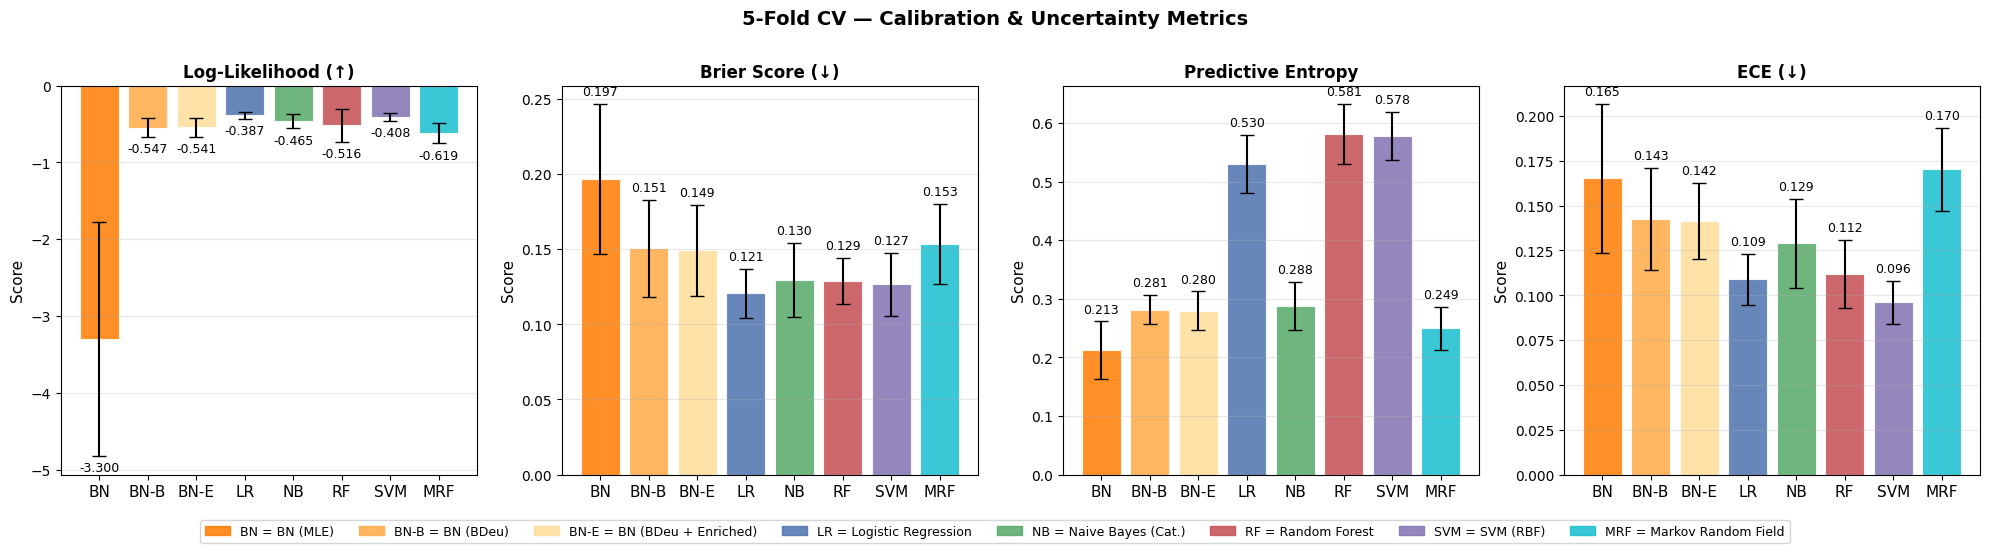

In [6]:
## ROC Curves (pooled predictions across all 5 folds)
COLORS = {
    'BayesianNetwork':    '#FF7C00',
    'BN_BDeu':            '#FFAA44',
    'BN_Enriched':        '#FFDD99',
    'LogisticRegression': '#4C72B0',
    'NaiveBayes':         '#55A868',
    'RandomForest':       '#C44E52',
    'SVM':                '#8172B2',
    'MRF':                '#17BECF',
}
DISPLAY_NAMES = {
    'BayesianNetwork':    'BN (MLE)',
    'BN_BDeu':            'BN (BDeu)',
    'BN_Enriched':        'BN (BDeu + Enriched)',
    'LogisticRegression': 'Logistic Regression',
    'NaiveBayes':         'Naive Bayes (Cat.)',
    'RandomForest':       'Random Forest',
    'SVM':                'SVM (RBF)',
    'MRF':                'Markov Random Field',
}

## Calibration & Uncertainty — Bar Charts (Log-likelihood, Brier, Entropy, ECE)

extra_metrics  = ['log_likelihood', 'brier', 'entropy', 'ece']
extra_labels   = ['Log-Likelihood (↑)', 'Brier Score (↓)', 'Predictive Entropy', 'ECE (↓)']
short_names    = ['BN', 'BN-B', 'BN-E', 'LR', 'NB', 'RF', 'SVM', 'MRF']
bar_colors     = [COLORS[m] for m in MODEL_NAMES]
x              = np.arange(len(MODEL_NAMES))

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, metric, mlabel in zip(axes, extra_metrics, extra_labels):
    means = [np.mean(cv_results[m][metric]) for m in MODEL_NAMES]
    stds  = [np.std(cv_results[m][metric])  for m in MODEL_NAMES]
    bars  = ax.bar(x, means, yerr=stds, capsize=5,
                   color=bar_colors, alpha=0.85, edgecolor='white', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(short_names, fontsize=11)
    ax.set_title(mlabel, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=11)
    ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
    ax.grid(axis='y', alpha=0.3)

legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=COLORS[m], alpha=0.85,
                  label=f'{short_names[i]} = {DISPLAY_NAMES[m]}')
    for i, m in enumerate(MODEL_NAMES)
]
fig.legend(handles=legend_patches, loc='lower center', ncol=8,
           fontsize=9, bbox_to_anchor=(0.5, -0.07))

plt.suptitle('5-Fold CV — Calibration & Uncertainty Metrics', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


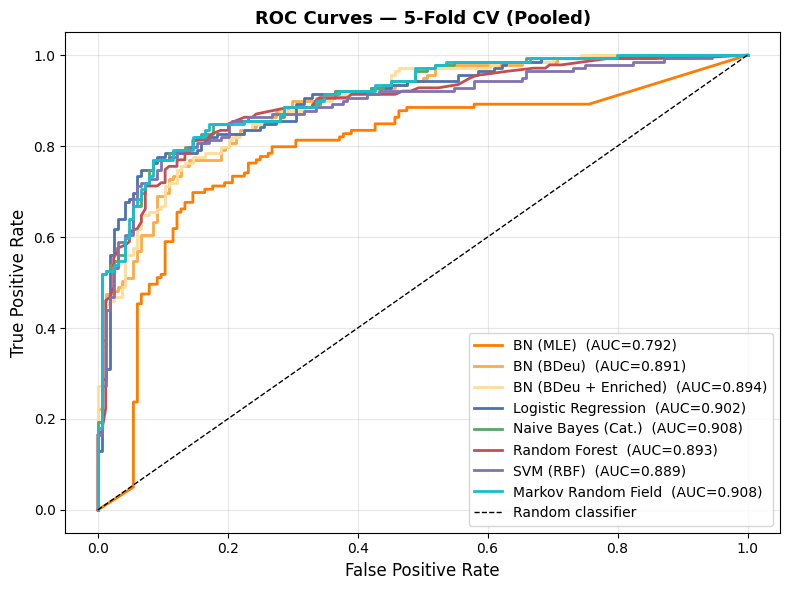

In [7]:


fig, ax = plt.subplots(figsize=(8, 6))
for name in MODEL_NAMES:
    yt  = np.array(pool_true[name])
    yp  = np.array(pool_proba[name])
    fpr, tpr, _ = roc_curve(yt, yp)
    auc = roc_auc_score(yt, yp)
    ax.plot(fpr, tpr, label=f'{DISPLAY_NAMES[name]}  (AUC={auc:.3f})',
            color=COLORS[name], linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — 5-Fold CV (Pooled)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


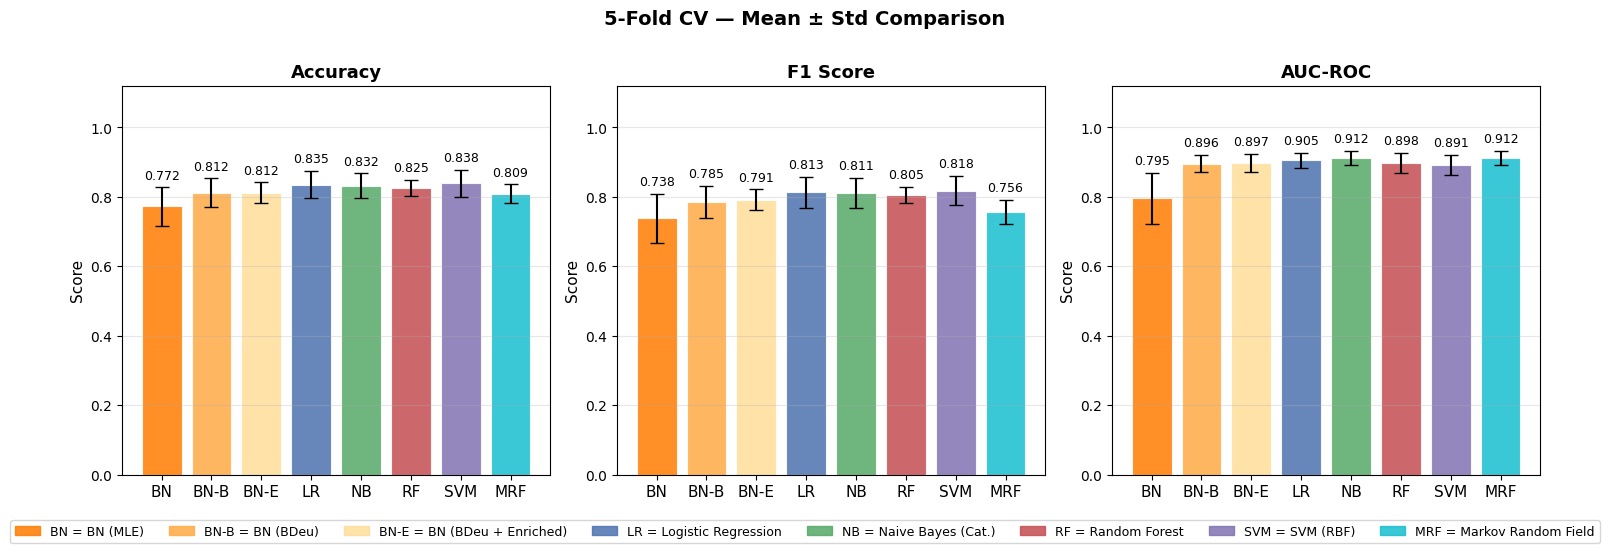

In [8]:
## Performance Bar Chart — Accuracy, F1, AUC
metrics_to_show = ['accuracy', 'f1', 'auc']
metric_labels   = ['Accuracy', 'F1 Score', 'AUC-ROC']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
x  = np.arange(len(MODEL_NAMES))
short_names = ['BN', 'BN-B', 'BN-E', 'LR', 'NB', 'RF', 'SVM', 'MRF']
bar_colors  = [COLORS[m] for m in MODEL_NAMES]

for ax, metric, mlabel in zip(axes, metrics_to_show, metric_labels):
    means = [np.mean(cv_results[m][metric]) for m in MODEL_NAMES]
    stds  = [np.std(cv_results[m][metric])  for m in MODEL_NAMES]
    bars  = ax.bar(x, means, yerr=stds, capsize=5,
                   color=bar_colors, alpha=0.85, edgecolor='white', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(short_names, fontsize=11)
    ax.set_ylim(0, 1.12)
    ax.set_title(mlabel, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score', fontsize=11)
    ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
    ax.grid(axis='y', alpha=0.3)

# Legend mapping short → full names
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=COLORS[m], alpha=0.85,
                  label=f'{short_names[i]} = {DISPLAY_NAMES[m]}')
    for i, m in enumerate(MODEL_NAMES)
]
fig.legend(handles=legend_patches, loc='lower center', ncol=8,
           fontsize=9, bbox_to_anchor=(0.5, -0.07))

plt.suptitle('5-Fold CV — Mean ± Std Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


Best baseline by AUC: NaiveBayes  (mean AUC = 0.9115)


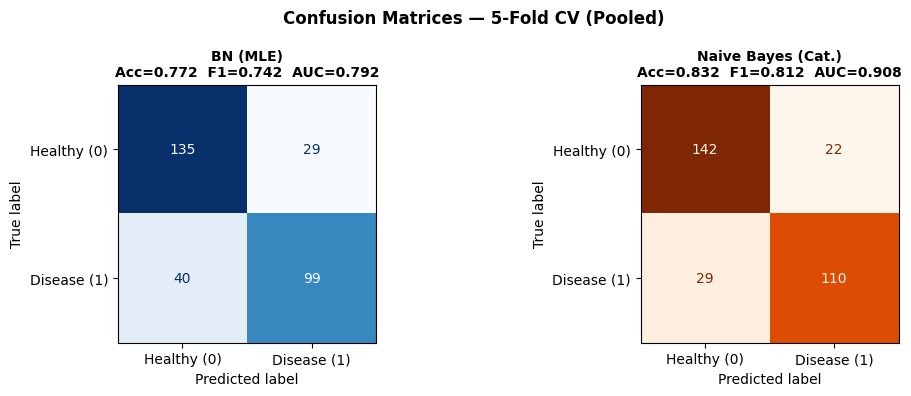

In [9]:
## Confusion Matrices — Bayesian Network vs Best Baseline (pooled CV predictions)

# Determine best baseline by mean AUC
baseline_names = [m for m in MODEL_NAMES if m != 'BayesianNetwork']
best_baseline  = max(baseline_names, key=lambda m: np.mean(cv_results[m]['auc']))
print(f"Best baseline by AUC: {best_baseline}  "
      f"(mean AUC = {np.mean(cv_results[best_baseline]['auc']):.4f})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, model_key, cmap in [
    (axes[0], 'BayesianNetwork', 'Blues'),
    (axes[1], best_baseline,     'Oranges'),
]:
    yt   = np.array(pool_true[model_key])
    yp   = (np.array(pool_proba[model_key]) >= 0.5).astype(int)
    cm   = confusion_matrix(yt, yp)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Healthy (0)', 'Disease (1)'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    acc  = accuracy_score(yt, yp)
    f1   = f1_score(yt, yp)
    auc  = roc_auc_score(yt, np.array(pool_proba[model_key]))
    ax.set_title(f'{DISPLAY_NAMES[model_key]}\n'
                 f'Acc={acc:.3f}  F1={f1:.3f}  AUC={auc:.3f}',
                 fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrices — 5-Fold CV (Pooled)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()